In [2]:
from ResearchFramework.ResearchHandler import ResearchHandler
import ResearchFramework.simulation as simu
import ResearchFramework.transforms as tf

fred = ResearchHandler("data/fred_master.csv")

In [3]:
not_date = fred.data.drop(columns=["date"])

In [26]:
## make correlation matrix
corr_matrix = not_date.corr()

ordered_corr_pairs = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
## make heatmap
# import seaborn as sns
# import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(50, 50))
# sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
# plt.title("Correlation Matrix Heatmap")
# plt.savefig("output_graphs/correlation_matrix_heatmap.png")
# fig;

In [21]:
op = pd.DataFrame(ordered_corr_pairs, columns=["Correlation"])
op.index = pd.MultiIndex.from_tuples(op.index, names=["Var1", "Var2"])
op = op.reset_index()
op = op[op["Var1"] != op["Var2"]]
op

,Var1,Var2,Correlation
1,PCE_Price_Index,Headline_CPI,0.999877
2,Core_CPI,Core_PCE,0.999690
3,Personal_Consumption_Expenditures,Nominal_GDP,0.999690
4,Core_PCE,PCE_Price_Index,0.999237
5,Core_PCE,Headline_CPI,0.999120
...,...,...,...
1690,Federal_Debt_Total,Labor_Force_Participation,-0.912478
1691,Commercial_Loans,Labor_Force_Participation,-0.914121
1692,M2_Money_Stock,Labor_Force_Participation,-0.919226
1693,Labor_Force_Participation,Total_Reserves,-0.962630


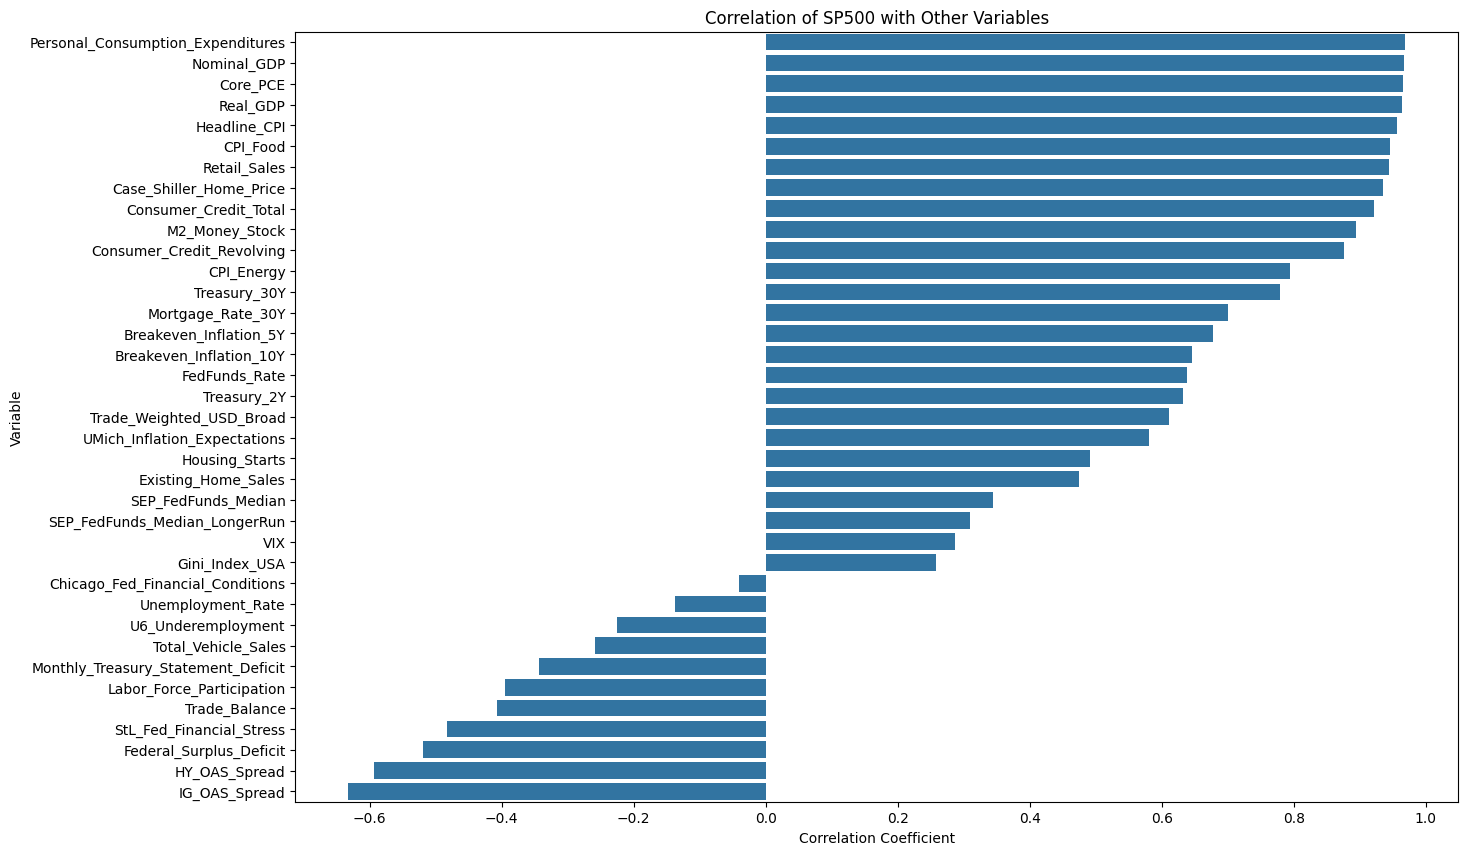

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sp500_corrs = op[(op["Var1"] == "SP500")].sort_values(by="Correlation", ascending=False)

fig = plt.figure(figsize=(15, 10))
sns.barplot(x="Correlation", y="Var2", data=sp500_corrs)
plt.title("Correlation of SP500 with Other Variables")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")
plt.savefig("output_graphs/sp500_correlations.png")
fig;

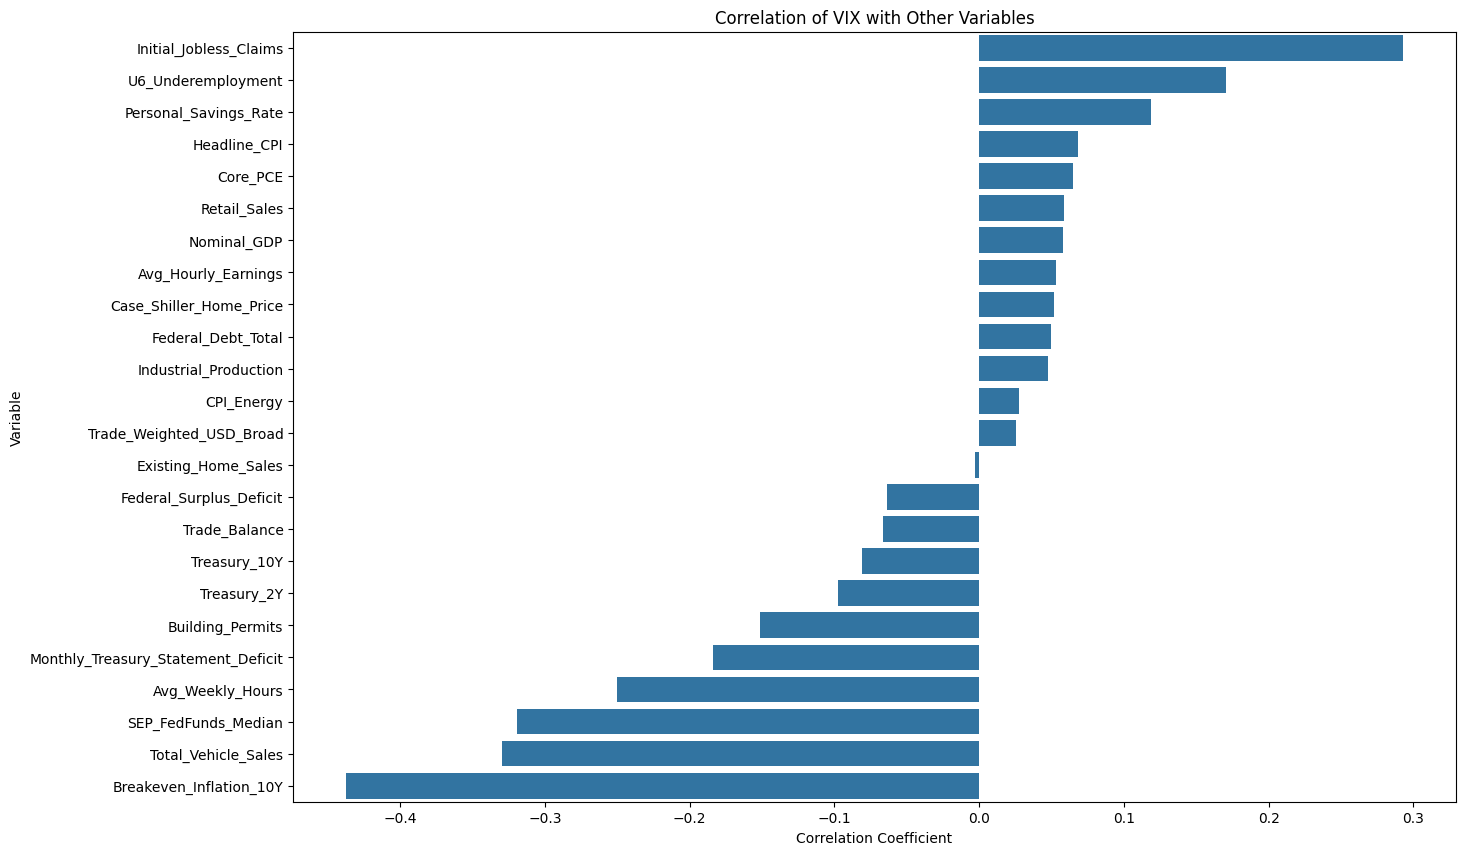

In [25]:
vix_corrs = op[(op["Var1"] == "VIX")].sort_values(by="Correlation", ascending=False)
fig = plt.figure(figsize=(15, 10))
sns.barplot(x="Correlation", y="Var2", data=vix_corrs)
plt.title("Correlation of VIX with Other Variables")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")
plt.savefig("output_graphs/vix_correlations.png")